# Other machine learning approaches for classification: XGBoost

In [49]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

random_seed = 10
random.seed(random_seed)
np.random.seed(random_seed)

## Data preparation
### Load data

In [50]:
data = pd.read_csv(os.path.join(".", "data", "features_30_sec.csv"))

X = data.iloc[:, 2:-1].values  # All feature columns
y = data.iloc[:, -1].values     # Label column

print(f"Dataset loaded:\n")
print(f"Total samples:     {len(X)}")
print(f"Features:          {X.shape[1]}")
print(f"Classes:           {sorted(set(y))}")
print(f"Samples per class: {pd.Series(y).value_counts().to_dict()}")


Dataset loaded:

Total samples:     1000
Features:          57
Classes:           ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Samples per class: {'blues': 100, 'classical': 100, 'country': 100, 'disco': 100, 'hiphop': 100, 'jazz': 100, 'metal': 100, 'pop': 100, 'reggae': 100, 'rock': 100}


In [51]:
classes = sorted(set(y))
class_dict = {classes[i]: i for i in range(10)}
y = np.vectorize(class_dict.get)(y)

### Split into training and test datasets

In [52]:
# Stratified train/test split to ensure balanced class distribution

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=random_seed, 
    stratify=y
)

print(f"Dataset split (stratified):\n")
print(f"Training:   {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test:       {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"Training class distribution: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Test class distribution:     {pd.Series(y_test).value_counts().to_dict()}")

Dataset split (stratified):

Training:   800 samples (80.0%)
Test:       200 samples (20.0%)
Training class distribution: {8: 80, 5: 80, 2: 80, 3: 80, 7: 80, 4: 80, 0: 80, 6: 80, 1: 80, 9: 80}
Test class distribution:     {0: 20, 6: 20, 2: 20, 9: 20, 1: 20, 3: 20, 7: 20, 4: 20, 8: 20, 5: 20}


## Define pipelines

In [53]:
model = xgb.XGBClassifier(
    num_class=10, 
    eval_metric='mlogloss',
    use_label_encoder=False,
    max_depth=4,
    learning_rate=0.3,
    n_estimators=100,
    random_state=random_seed
)

model.fit(X_train, y_train)

c:\Users\mathi\miniconda3\envs\ml-projects\lib\site-packages\xgboost\training.py:200: UserWarning: [16:38:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [54]:
# Predict class labels
y_pred = model.predict(X_test)

# Predict class probabilities
y_prob = model.predict_proba(X_test)

In [55]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
cv_results = {}

# Perform 5-fold cross-validation
scores = cross_val_score(
    model, X_train, y_train, 
    cv=cv, 
    scoring='accuracy',
    n_jobs=-1
)

cv_results["XGB"] = {
    'cv_mean': scores.mean(),
    'cv_std': scores.std(),
    'cv_scores': scores
}

print(f"Cross-validation accuracy: {scores.mean():.3f} ± {scores.std():.3f}")
print(f"Fold scores:               {[f'{s:.3f}' for s in scores]}")

Cross-validation accuracy: 0.714 ± 0.029
Fold scores:               ['0.706', '0.719', '0.662', '0.744', '0.738']


## Tuning hyperparameters
### Pipeline for tuning

In [56]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'learning_rate': [0.05, 0.1, 0.3, 0.5],
}

print(f"\nSearching {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['learning_rate'])} combinations...")

# Grid search with cross-validation
grid_search = GridSearchCV(
    model,
    param_grid,
    cv=cv,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)
print(f"Best cross-validation score: {grid_search.best_score_:.3f}")



Searching 64 combinations...
Fitting 5 folds for each of 64 candidates, totalling 320 fits


c:\Users\mathi\miniconda3\envs\ml-projects\lib\site-packages\xgboost\training.py:200: UserWarning: [16:46:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best cross-validation score: 0.711


Best parameters found in grid search:

In [57]:
grid_search.best_params_

{'learning_rate': 0.1, 'max_depth': None, 'n_estimators': 500}

In [58]:
# Get the best model
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Set Accuracy:            {test_accuracy:.3f}")
print(f"CV accuracy (for comparison): {grid_search.best_score_:.3f}")
print(f"Difference:                   {abs(test_accuracy - grid_search.best_score_):.3f}\n")

if abs(test_accuracy - grid_search.best_score_) < 0.05:
    print("CV and test scores are close (< 5% difference)")
else:
    print("Warning: > 5\% difference between CV and test scores")

# Classification report
print("\n" + "="*55)
print("Classification report:")
print("="*55)
print(classification_report(y_test, y_pred))

Test Set Accuracy:            0.715
CV accuracy (for comparison): 0.711
Difference:                   0.004

CV and test scores are close (< 5% difference)

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.65      0.74        20
           1       0.85      0.85      0.85        20
           2       0.65      0.65      0.65        20
           3       0.71      0.60      0.65        20
           4       0.70      0.80      0.74        20
           5       0.79      0.75      0.77        20
           6       0.83      0.95      0.88        20
           7       0.85      0.85      0.85        20
           8       0.65      0.55      0.59        20
           9       0.38      0.50      0.43        20

    accuracy                           0.71       200
   macro avg       0.73      0.71      0.72       200
weighted avg       0.73      0.71      0.72       200



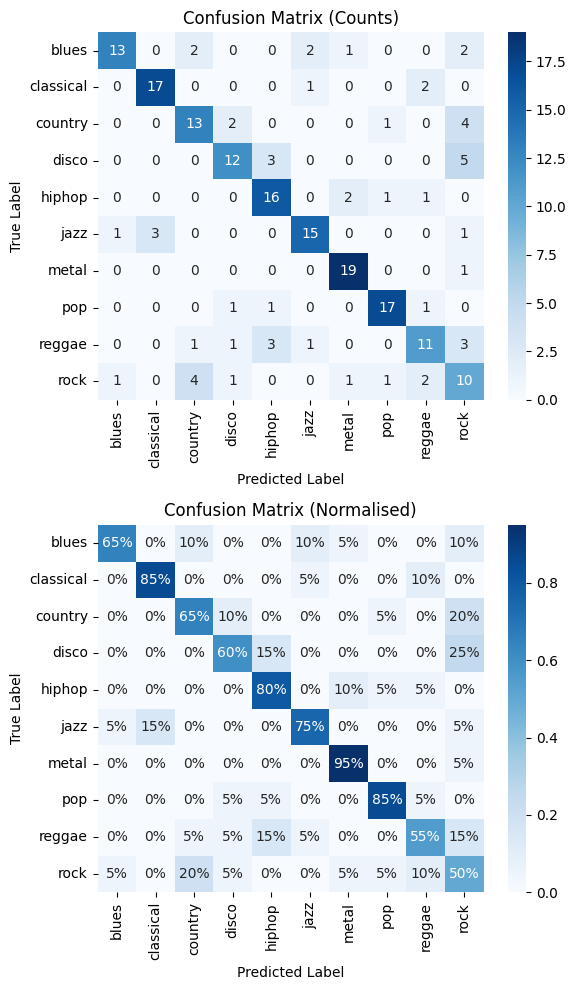

In [59]:
# Assemble confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=range(10))
cm_normalised = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6,10))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=classes, yticklabels=classes)
ax1.set_title('Confusion Matrix (Counts)')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# Normalised (percentages)
sns.heatmap(cm_normalised, annot=True, fmt='.0%', cmap='Blues', ax=ax2,
            xticklabels=classes, yticklabels=classes)
ax2.set_title('Confusion Matrix (Normalised)')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()
